### Diffusion Solver
#### Written by: Anand Mathew

## Opening Rituals

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Tuple, Dict, Any
from scipy.sparse import lil_matrix, csr_matrix

from scipy.sparse.linalg import spsolve
import meshio

import sys
from pathlib import Path

import inspect

from IPython.display import Image, display

In [9]:
import add_paths

from FemFrameWork.create_id_matrix import create_id_matrix
from FemFrameWork.gauss_quadrature import GaussPoints
from FemFrameWork.shape_functions import ShapeFunctions
from FemFrameWork.vector import Vector

from Physics_models.diffusion_kernel import CalculateLocalMatrices, Get_DMat, Get_VolumetricSource
from Kernel.general_kernel import CalculateGlobalMatrices, Assemble, Create_ConstraintsVector, PostProcessing
from Kernel.writeVTK import write_vtk

import importlib

## Driver to run a steady-state diffusion simulation

In [10]:
def Driver_Steady_Diffusion(Coord: np.ndarray, Connectivity: np.ndarray, constraints: np.ndarray,
                            diffusivity_function: Dict[str, Any], load_type: Dict[str, Any], EleType: str,
                            dofs_per_node: int, dim: int, NGPTS: int, vtk_filename: str = "solution.vtk") -> np.ndarray:
    """
    Final FEM pipeline for steady-state diffusion.

    Parameters
    ----------
    Coord
    Connectivity 
    constraints : (NCons, 3)
    diffusivity_function : dict
        Passed straight to Get_DMat inside CalculateLocalMatrices.
    load_type : dict
        Passed straight to Get_VolumetricSource.
    EleType : str
        Element type (e.g., "Q4").
    dofs_per_node : int
        DOFs per node (1 for diffusion problems).
    dim : int
        Spatial dimension (1, 2, or 3).
    NGPTS : int
        Number of Gauss points to use per element.
    vtk_filename : str, optional
        Output filename for VTK export (default: "solution.vtk").

    Returns
    -------
    U : (NumNodes, dofs_per_node)
        Full nodal solution (free + prescribed).
    """
    # Basic derived quantities
    NumNodes = Coord.shape[0]
    Nele = Connectivity.shape[0]
    NCons = constraints.shape[0]

    print("──────── Simulation status report ────────")
    print(f"Nodes={NumNodes}, Elems={Nele}, DOFs/node={dofs_per_node}")

    # Create GlobalID, NEqns
    GlobalID, NEqns = create_id_matrix(constraints, dofs_per_node, NumNodes)
    print(f"[1/6] GlobalID created. NEqns = {NEqns}, NCons = {NCons}")

    # Constraint
    U_P = Create_ConstraintsVector(constraints, GlobalID)
    print("[2/6] U_P created.")

    # Create global matrices 
    K_FF, K_FP, K_PP, R_F, R_P = CalculateGlobalMatrices(
        Connectivity=Connectivity,
        Coord=Coord,
        diffusivity_function=diffusivity_function,
        dim=dim,
        dofs_per_node=dofs_per_node,
        EleType=EleType,
        GlobalID=GlobalID,
        load_type=load_type,
        NCons=NCons,
        Nele=Nele,
        NEqns=NEqns,
        NGPTS=NGPTS,
    )
    print("[3/6] Global matrices assembled.")

    # Solve
    RHS = R_F - K_FP @ U_P
    U_F = spsolve(K_FF, RHS)
    print("[4/6] Linear system solved.")

    # Post processing 
    U = PostProcessing(GlobalID, U_F, U_P)
    print("[5/6] Postprocessing done.")

    # Write VTK output
    write_vtk(vtk_filename, Coord, Connectivity, EleType, U)
    print(f"[6/6] VTK written to {vtk_filename}")

    print("FEM simulation complete!")
    return U

## A posteriori error analysis

In [11]:
def Calculate_Error(Connectivity: np.ndarray,
                    Coord: np.ndarray,
                    EleType: str,
                    NGPTS: int,
                    U: np.ndarray,
                    exact_solution,
                    exact_gradient) -> tuple[float, float]:
    """
    Compute L2 and H1-seminorm errors of the FEM solution.

    Parameters
    ----------
    Connectivity : (Nele, nen)
        Element connectivity array (0-based node indices).
    Coord : (Nnodes, dim)
        Global coordinates of all nodes.
    EleType : str
        Element type (e.g., "Q4", "T3", etc.).
    NGPTS : int
        Number of Gauss points per direction.
    U : (Nnodes, 1)
        Nodal solution vector (including prescribed and free DOFs).
    exact_solution : callable
        Function handle f(x, y) returning the analytical (exact) solution.
    exact_gradient : callable
        Function handle grad_f(x, y) returning ∇u_exact = [du/dx, du/dy].

    Returns
    -------
    error_in_L2 : float
        L2 norm of the error.
    error_in_H1_seminorm : float
        H1 seminorm of the error.
    """

    # Initializing
    error_in_L2 = 0.0
    error_in_H1 = 0.0

    if Connectivity.min() == 1:
        Connectivity = Connectivity - 1

    Nele = Connectivity.shape[0]
    dim = Coord.shape[1]

    U = np.asarray(U).reshape(-1)

    # Gauss points
    r, w = GaussPoints(dim, EleType, NGPTS)

    for ele in range(Nele):
        EleNodes = Connectivity[ele, :]  

        # nodal values for this element
        uCap = U[EleNodes].reshape(-1, 1)   
        xCap = Coord[EleNodes, :]              
        for gpt in range(len(w)):
            zeta = np.array([r[gpt]]) if r.ndim == 1 else r[gpt, :].reshape(1, -1)

            N, DN = ShapeFunctions(EleType, zeta)
            N = np.array(N).flatten()        

            x = (xCap.T @ N).flatten()       
            J = xCap.T @ DN
            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)

            B = DN @ invJ                      

            # interpolate u
            u = float(N @ uCap.squeeze())
            gradu = (B.T @ uCap).squeeze()   

            # exact
            uExact = float(exact_solution(*x))
            duExact = np.asarray(exact_gradient(*x))

            # L2 
            error_in_L2 += w[gpt] * (u - uExact) ** 2 * detJ

            # H1 
            delGrad = gradu - duExact[:dim]
            error_in_H1 += w[gpt] * (delGrad @ delGrad) * detJ

    return np.sqrt(error_in_L2), np.sqrt(error_in_H1)

## Verification using an analytical solution

#### Diffusion problem for a 2D plate with lengths 2 units on each side. BVP is given as

Governing Eqn:
$$
-\left( 
\frac{\partial^2 c}{\partial x^2} + 
\frac{\partial^2 c}{\partial y^2} 
\right)
= f(x,y)
= \sin\!\left(\frac{\pi x}{2}\right)
  \sin\!\left(\frac{\pi y}{2}\right),
\quad (x,y) \in (0,2)\times(0,2)
$$
BCs:
$$
c(x=0,y) = c(x=2,y) = c(x,y=0) = c(x,y=2) = 0
$$

Analytical solution

$$
c(x,y)
= \frac{2}{\pi^2}
\sin\!\left(\frac{\pi x}{2}\right)
\sin\!\left(\frac{\pi y}{2}\right)
$$

#### 15x15 nodes check 

In [12]:
data = np.load("/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/bvp_L2x2_Q4_15x15.npz")
Coord = data["Coord"]
Connectivity = data["Connectivity"]
Constraints = data["Constraints"]
Lx = float(data["Lx"])
Ly = float(data["Ly"])

In [13]:
# Solving

diffusivity_function = {"type": "scalar", "d0": 1.0}

load_type = {
    "type": "function",
    "f": lambda x: np.sin(np.pi * x[0] / 2.0) * np.sin(np.pi * x[1] / 2.0)
}


U = Driver_Steady_Diffusion(Coord, Connectivity, Constraints, diffusivity_function,
                           load_type, "q4",1, 2, 3, "diffusion_2dplate_15x15nodes.vtk")

──────── Simulation status report ────────
Nodes=256, Elems=225, DOFs/node=1
[1/6] GlobalID created. NEqns = 196, NCons = 60
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to diffusion_2dplate_15x15nodes.vtk
FEM simulation complete!


#### Analytical Solution

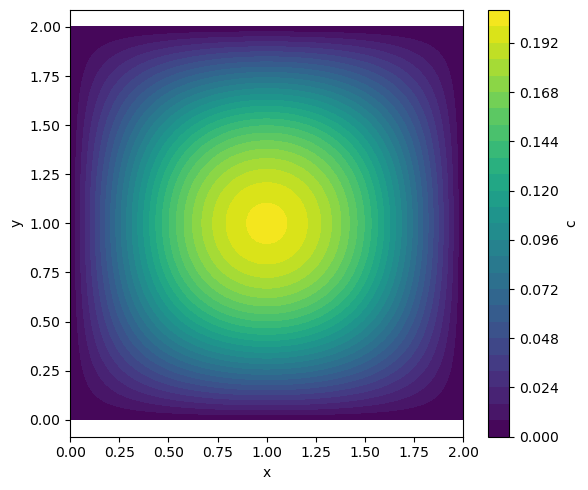

In [14]:
Lx = 2.0
Ly = 2.0
nx, ny = 100, 100
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# sol
c = (2 / np.pi**2) * np.sin(np.pi * X / 2) * np.sin(np.pi * Y / 2)

# plot
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, c, levels=30, cmap="viridis")
plt.colorbar(contour, label="c")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

#### FEM solution

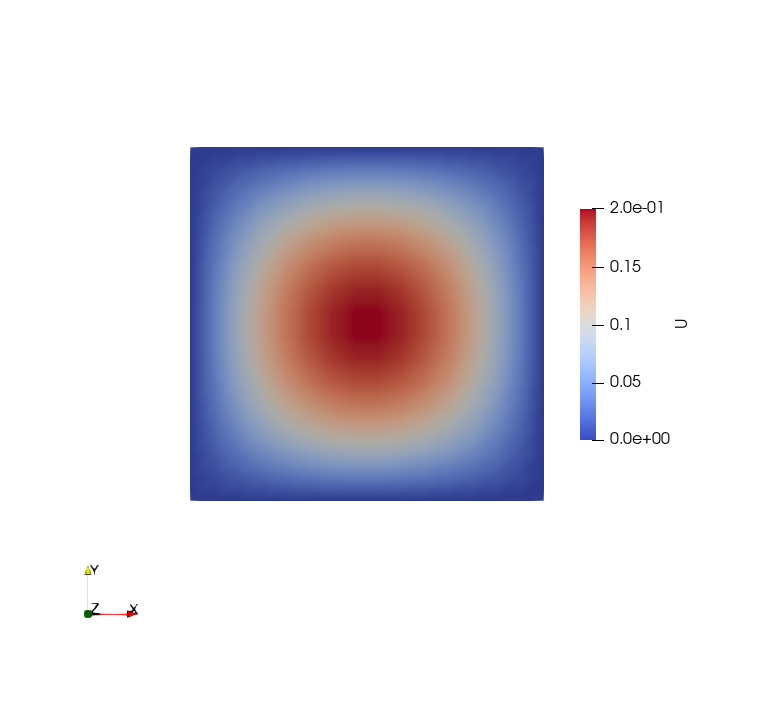

In [15]:
display(Image(filename="pictures/sqplate_15x15.png", embed=True))

In [16]:
def exact_solution(x, y):
    return (2.0 / np.pi**2) * np.sin(np.pi * x / Lx) * np.sin(np.pi * y / Ly)

def exact_gradient(x, y):
    # dc/dx
    dc_dx = (1.0 / np.pi) * np.cos(np.pi * x / Lx) * np.sin(np.pi * y / Ly)
    # dc/dy
    dc_dy = (1.0 / np.pi) * np.sin(np.pi * x / Lx) * np.cos(np.pi * y / Ly)
    return np.array([dc_dx, dc_dy])

In [17]:
err_L2, err_H1 = Calculate_Error(Connectivity, Coord, "q4", 3, U, exact_solution, exact_gradient)

In [18]:
print(err_L2)
print(err_H1)

0.0008764124891935922
0.02720668655290068


──────── Simulation status report ────────
Nodes=25, Elems=16, DOFs/node=1
[1/6] GlobalID created. NEqns = 9, NCons = 16
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to 2d_diff_plate_4x4.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=81, Elems=64, DOFs/node=1
[1/6] GlobalID created. NEqns = 49, NCons = 32
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to 2d_diff_plate_8x8.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=289, Elems=256, DOFs/node=1
[1/6] GlobalID created. NEqns = 225, NCons = 64
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to 2d_diff_plate_16x16.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=1089, Elems=1024, DOFs/node=1
[1/6] GlobalID created. NE

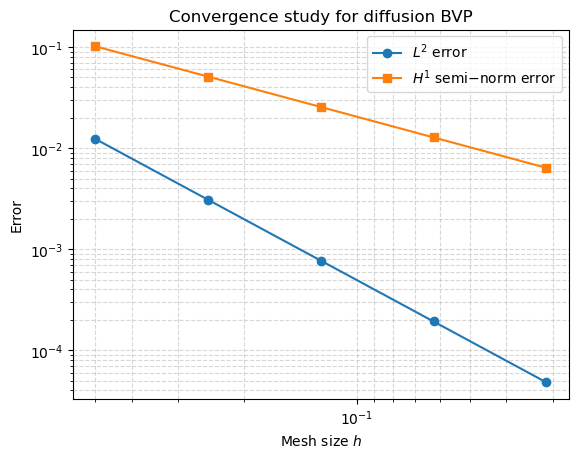

In [19]:
files = [
    "/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_platemesh_4x4.npz",
    "/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_platemesh_8x8.npz", 
    "/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_platemesh_16x16.npz",
    "/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_platemesh_32x32.npz",
    "/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_platemesh_64x64.npz",
]

output_files = [
    "2d_diff_plate_4x4.vtk",
    "2d_diff_plate_8x8.vtk",
    "2d_diff_plate_16x16.vtk",
    "2d_diff_plate_32x32.vtk",
    "2d_diff_plate_64x64.vtk",
]

dim = 2
NGPTS = 4

def exact_solution_xyL(x, y, Lx, Ly):
    return (2.0 / np.pi**2) * np.sin(np.pi * x / Lx) * np.sin(np.pi * y / Ly)

def exact_gradient_xyL(x, y, Lx, Ly):
    dc_dx = (1.0 / np.pi) * np.cos(np.pi * x / Lx) * np.sin(np.pi * y / Ly)
    dc_dy = (1.0 / np.pi) * np.sin(np.pi * x / Lx) * np.cos(np.pi * y / Ly)
    return np.array([dc_dx, dc_dy])

diffusivity_function = {"type": "scalar", "d0": 1.0}

# storage
h_list = []
L2 = []
H1 = []

for fname, out in zip(files, output_files):
    data = np.load(fname)
    Coord = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints = data["Constraints"]
    Lx = float(data["Lx"])
    Ly = float(data["Ly"])

    # load_type depends on Lx, Ly for this RHS
    load_type = {
        "type": "function",
        "f": lambda x, Lx=Lx, Ly=Ly: np.sin(np.pi * x[0] / Lx) * np.sin(np.pi * x[1] / Ly),
    }

    # solve
    U = Driver_Steady_Diffusion(Coord, Connectivity, Constraints, diffusivity_function,
                                load_type, "q4", 1, dim, NGPTS, out)

    def exact_solution_local(x, y, Lx=Lx, Ly=Ly):
        return exact_solution_xyL(x, y, Lx, Ly)

    def exact_gradient_local(x, y, Lx=Lx, Ly=Ly):
        return exact_gradient_xyL(x, y, Lx, Ly)

    err_L2, err_H1 = Calculate_Error(
        Connectivity,
        Coord,
        "q4",
        NGPTS,
        U,
        exact_solution_local,
        exact_gradient_local,
    )

    # mesh size h from x-coordinates (ChatGPT idea)
    unique_x = np.unique(Coord[:, 0])
    nx = len(unique_x)
    h_val = Lx / (nx - 1)

    h_list.append(h_val)
    L2.append(err_L2)
    H1.append(err_H1)

# to arrays
h_arr = np.array(h_list)
L2_arr = np.array(L2)
H1_arr = np.array(H1)

def terminal_rate(h_arr, err_arr):
    h1, h2 = h_arr[-2], h_arr[-1]
    e1, e2 = err_arr[-2], err_arr[-1]
    return -np.log(e2 / e1) / np.log(h2 / h1)

p_L2 = terminal_rate(h_arr, L2_arr)
p_H1 = terminal_rate(h_arr, H1_arr)

print(f"Terminal convergence rate (L2):  {p_L2}")
print(f"Terminal convergence rate (H1):  {p_H1}")

# plot (ChatGPT)
plt.figure()
plt.loglog(h_arr, L2_arr, marker="o", label=r"$L^2$ error")
plt.loglog(h_arr, H1_arr, marker="s", label=r"$H^1$ semi$-$norm error")
plt.gca().invert_xaxis()
plt.xlabel(r"Mesh size $h$")
plt.ylabel("Error")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.title("Convergence study for diffusion BVP")
plt.show()

h is in decreasing order i.e. mesh is bnecoming finer and finer.

Terminal convergence rate (L2):  -1.999982409419573

Terminal convergence rate (H1):  -0.9999132838475366

Visualization with different mesh sizes

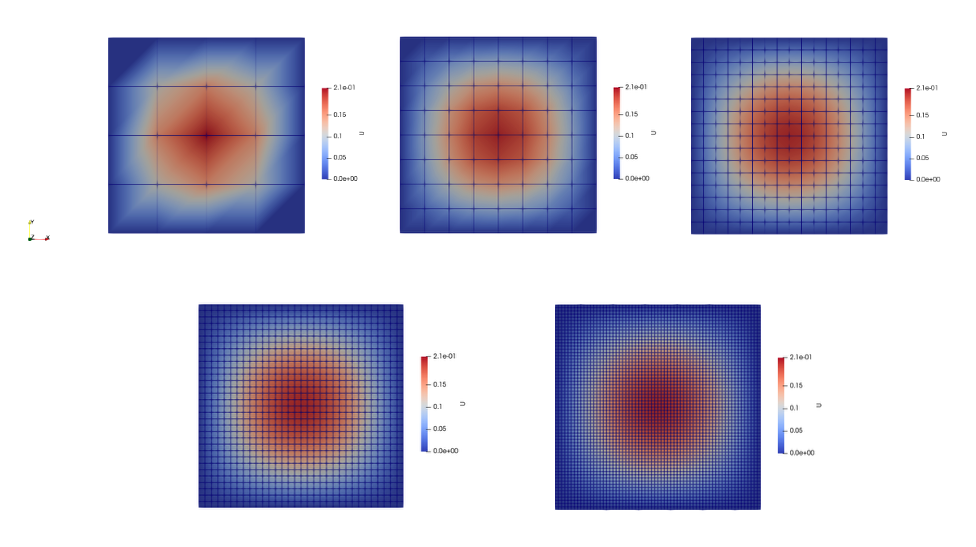

In [20]:
display(Image(filename="pictures/combined_nodes_pic.png", embed=True))

## Solving problems that do not have analytical solutions

### Problem 1: L shaped plate

In [21]:
data = np.load("/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_Lshape_64x64.npz")
Coord = data["Coord"]
Connectivity = data["Connectivity"]
Constraints = data["Constraints"]

In [22]:
diffusivity_function = {"type": "scalar", "d0": 1.0}

load_type = {
    "type": "constant",
    "f0": 1.0
}

dim = 2
NGPTS = 5

U = Driver_Steady_Diffusion(Coord, Connectivity, Constraints, diffusivity_function,
                           load_type, "q4", 1, dim, NGPTS, "diffusion_2dLshaped_q4.vtk")

──────── Simulation status report ────────
Nodes=3264, Elems=3072, DOFs/node=1
[1/6] GlobalID created. NEqns = 2945, NCons = 319
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to diffusion_2dLshaped_q4.vtk
FEM simulation complete!


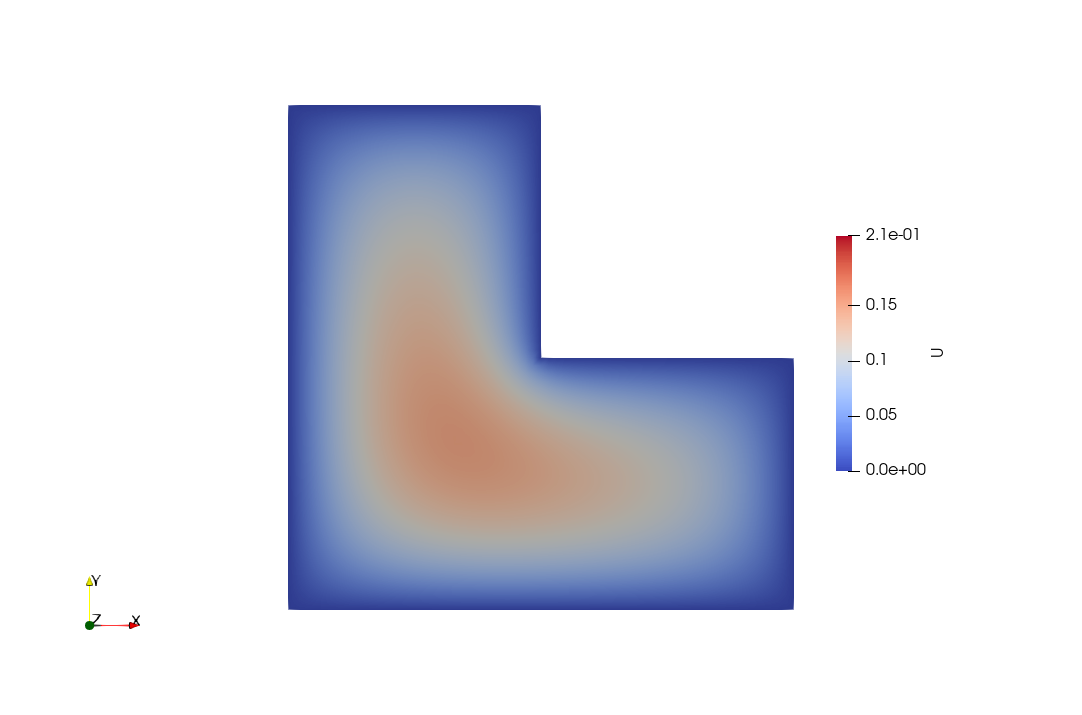

In [23]:
display(Image(filename="pictures/Lshaped_q4.png", embed=True))

#### T3 element

In [24]:
data = np.load("/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/t3_Lshape_64x64.npz")
Coord = data["Coord"]
Connectivity = data["Connectivity"]
Constraints = data["Constraints"]

In [25]:
diffusivity_function = {"type": "scalar", "d0": 1.0}

load_type = {
    "type": "constant",
    "f0": 1.0
}

dim = 2
NGPTS = 3

U = Driver_Steady_Diffusion(Coord, Connectivity, Constraints, diffusivity_function,
                           load_type, "t3", 1, dim, NGPTS, "diffusion_2dLshaped_t3.vtk")

──────── Simulation status report ────────
Nodes=3264, Elems=6144, DOFs/node=1
[1/6] GlobalID created. NEqns = 2945, NCons = 319
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to diffusion_2dLshaped_t3.vtk
FEM simulation complete!


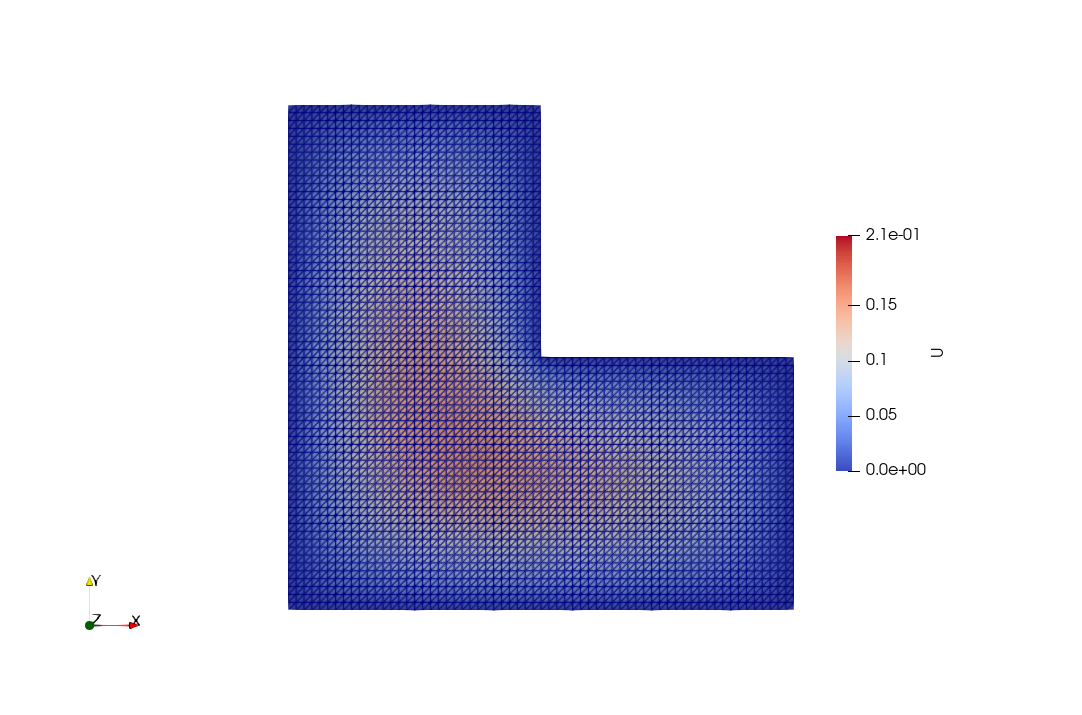

In [26]:
display(Image(filename="pictures/Lshaped_t3.png", embed=True))

There is a reentrant corner in this problem so the gradient will be singular at that point

### Problem 2: Plate with square hole

In [27]:
data = np.load("/Users/amathe28/Desktop/FEM/MyFEMproject_AnandMathew/DataFiles/q4_squarehole_64x64_inner1.npz")
Coord = data["Coord"]
Connectivity = data["Connectivity"]
Constraints = data["Constraints"]

In [28]:
diffusivity_function = {
    "type": "rotation",
    "theta": np.pi / 6.0,
    "d1": 10000.0,        
    "d2": 0.0              
}

load_type = {
    "type": "constant",
    "f0": 0.0
}

dim = 2
NGPTS = 5

U = Driver_Steady_Diffusion(Coord, Connectivity, Constraints, diffusivity_function,
                           load_type, "q4", 1, dim, NGPTS, "diffusion_2dsquarehole_q4.vtk")

──────── Simulation status report ────────
Nodes=4176, Elems=4032, DOFs/node=1
[1/6] GlobalID created. NEqns = 3888, NCons = 288
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to diffusion_2dsquarehole_q4.vtk
FEM simulation complete!


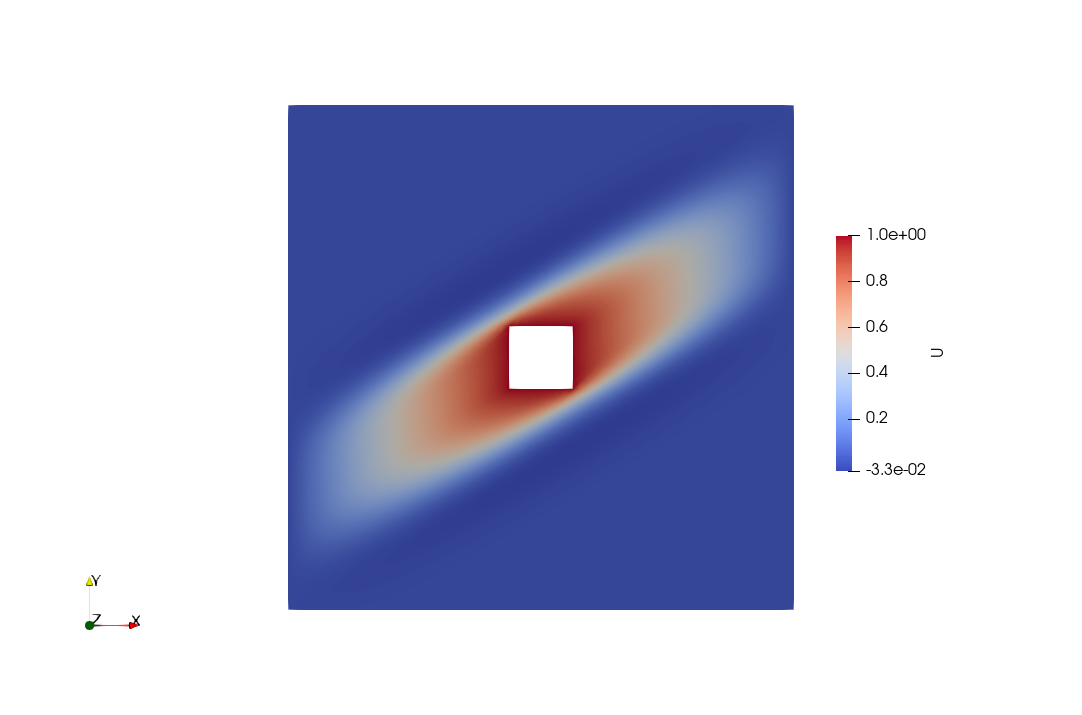

In [29]:
display(Image(filename="pictures/sqplate_hole_q4.png", embed=True))

The concentrations is negetive. As Gelarkin formalim doesnt enforce positivity.